In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch import nn
import numpy as np

# Lineer vs Non-Lineer Sınıflandırma

Sismik aktivite verisiyle ikili sınıflandırma (0/1): sismik olay var mı yok mu?

- **Lineer model** (aktivasyon yok): ~%50 doğruluk — veri düz çizgiyle ayrılamadığı için başarısız
- **Non-lineer model** (ReLU aktivasyon): ~%100 doğruluk — eğri karar sınırları öğrenebiliyor

In [2]:
# Sismik aktivite verisi: dalga enerjisi + titreşim eksen değişimi → olay var mı (0/1)
df=pd.read_csv("08-seismic_activity_svm.csv")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   underground_wave_energy   400 non-null    float64
 1   vibration_axis_variation  400 non-null    float64
 2   seismic_event_detected    400 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB


In [3]:
# Sınıf dağılımını kontrol et: 0 ve 1 eşit mi? (dengesiz veri sorun yaratır)
df["seismic_event_detected"].value_counts()

seismic_event_detected
0    200
1    200
Name: count, dtype: int64

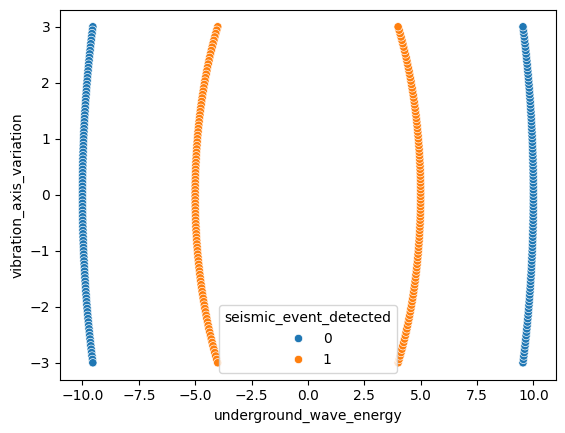

In [4]:
# İki özelliği eksene al, rengi sınıfa göre ayır
# Noktalar düz çizgiyle ayrılıyor mu (lineer) yoksa karmaşık mı görmek için
sns.scatterplot(data=df,x="underground_wave_energy",y="vibration_axis_variation",hue="seismic_event_detected")
plt.show()

In [5]:
# İki özellik kolonu → numpy array
X=df[["underground_wave_energy","vibration_axis_variation"]].values
# Hedef kolon: 0 veya 1
y=df["seismic_event_detected"].values

from sklearn.model_selection import train_test_split
# %80 eğitim, %20 test. random_state=42 → her çalıştırmada aynı bölünme
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

len(X_train),len(X_test),len(y_train),len(y_test)

(320, 80, 320, 80)

In [6]:
# Tensor'a çevirmeden önce şekil kontrolü: X → (N,2), y → (N,)
print(X_train.shape,y_train.shape
      ,X_test.shape,y_test.shape)

(320, 2) (320,) (80, 2) (80,)


In [7]:
# Numpy array → PyTorch tensor
X_train=torch.tensor(X_train,dtype=torch.float32)
X_test=torch.tensor(X_test,dtype=torch.float32)

# unsqueeze(1): (N,) → (N,1). Loss fonksiyonu y ile y_pred'in şeklinin aynı olmasını bekler
y_train=torch.tensor(y_train,dtype=torch.float32).unsqueeze(1)
y_test=torch.tensor(y_test,dtype=torch.float32).unsqueeze(1)

In [8]:
# Tensor'a çevirdikten sonra şekil kontrolü: X → (N,2), y → (N,1)
print(X_train.shape,y_train.shape
      ,X_test.shape,y_test.shape)

torch.Size([320, 2]) torch.Size([320, 1]) torch.Size([80, 2]) torch.Size([80, 1])


In [ ]:
"""
LİNEER MODEL DENEMESİ (başarısız — karşılaştırma için)

Aktivasyon fonksiyonu olmadan kaç katman eklenirse eklensin model lineer kalır.
Bu veri lineer ayrılamadığı için ~%50 doğrulukta takılıp kaldı (rastgele tahminle aynı).
Çözüm: ReLU gibi bir aktivasyon fonksiyonu eklemek.
"""

"""
class ClassificationLinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1=nn.Linear(in_features=2,out_features=10)
        self.layer_2=nn.Linear(in_features=10,out_features=10)
        self.layer_3=nn.Linear(in_features=10,out_features=1)
        
    def forward(self,x):
        return self.layer_3(self.layer_2(self.layer_1(x)))
    
model=ClassificationLinearModel()
"""

"""
Epoch: 0 | Loss: 0.7767497301101685 | Accuracy: 48.75 | Test Loss: 0.712154746055603 | Test Accuracy: 55.00000000000001
Epoch: 40 | Loss: 0.6924691200256348 | Accuracy: 50.625 | Test Loss: 0.6985043287277222 | Test Accuracy: 46.25
Epoch: 80 | Loss: 0.6913160085678101 | Accuracy: 51.87500000000001 | Test Loss: 0.7091559171676636 | Test Accuracy: 42.5
Epoch: 120 | Loss: 0.6913098096847534 | Accuracy: 52.1875 | Test Loss: 0.7100221514701843 | Test Accuracy: 41.25
Epoch: 160 | Loss: 0.6913095712661743 | Accuracy: 52.1875 | Test Loss: 0.7097902297973633 | Test Accuracy: 42.5
Epoch: 200 | Loss: 0.6913095712661743 | Accuracy: 52.1875 | Test Loss: 0.7098172903060913 | Test Accuracy: 42.5
Epoch: 240 | Loss: 0.6913095712661743 | Accuracy: 52.1875 | Test Loss: 0.7098150849342346 | Test Accuracy: 42.5
Epoch: 280 | Loss: 0.6913095712661743 | Accuracy: 52.1875 | Test Loss: 0.7098150849342346 | Test Accuracy: 42.5
Epoch: 320 | Loss: 0.6913095712661743 | Accuracy: 52.1875 | Test Loss: 0.7098150253295898 | Test Accuracy: 42.5
Epoch: 360 | Loss: 0.6913095712661743 | Accuracy: 52.1875 | Test Loss: 0.7098150849342346 | Test Accuracy: 42.5
Epoch: 400 | Loss: 0.6913095712661743 | Accuracy: 52.1875 | Test Loss: 0.7098150849342346 | Test Accuracy: 42.5
Epoch: 440 | Loss: 0.6913095712661743 | Accuracy: 52.1875 | Test Loss: 0.7098150849342346 | Test Accuracy: 42.5
Epoch: 480 | Loss: 0.6913095712661743 | Accuracy: 52.1875 | Test Loss: 0.7098150849342346 | Test Accuracy: 42.5
"""

In [10]:
# ── NON-LİNEER MODEL ─────────────────────────────────────────────────────────
class ClassificationNonLinear(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1=nn.Linear(in_features=2,out_features=10)   # 2 giriş → 10 nöron
        self.layer_2=nn.Linear(in_features=10,out_features=10)  # 10 → 10 (ara katman)
        self.layer_3=nn.Linear(in_features=10,out_features=1)   # 10 → 1 çıkış (logit)
        self.relu=nn.ReLU()  # Aktivasyon fonksiyonu: negatif değerleri 0 yapar, pozitifler kalır
        
    def forward(self,x):
        # ReLU katmanlar arasına girince model eğri sınırlar öğrenebilir (non-lineer)
        # Akış: x → layer1 → ReLU → layer2 → ReLU → layer3 → logit
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))
    
model=ClassificationNonLinear()

In [11]:
# BCEWithLogitsLoss: ikili sınıflandırma için kayıp (içinde sigmoid var, logit göndereceğiz)
loss_fn=nn.BCEWithLogitsLoss()
# Adam: SGD'den daha akıllı optimizer, her ağırlık için ayrı öğrenme hızı ayarlar
optimizer=torch.optim.Adam(params=model.parameters(),lr=0.001)

In [12]:
def calculate_accuracy(y_test,y_pred):
    # torch.eq: iki tensoru karşılaştırır, eşit olan yerler True
    correct=torch.eq(y_test,y_pred).sum().item()
    accuracy=(correct/len(y_pred)) * 100
    return accuracy

# ── EĞİTİMDEN ÖNCE HIZLI TEST ────────────────────────────────────────────────

# Ham çıktı: [-∞,+∞] arasında sayı (henüz 0/1 değil)
y_logits=model(X_test)[:5]
y_logits

# sigmoid: logit → [0,1] olasılığa çevir
y_pred_probs=torch.sigmoid(y_logits)
y_pred_probs

# round: 0.5 üzeri → 1, altı → 0 (kesin sınıf etiketi)
y_preds=torch.round(y_pred_probs)
y_preds

# Karşılaştırmak için gerçek etiketler
y_test[:5]

# Eğitim öncesi doğruluk (rastgele ağırlıklarla düşük olması normal)
calculate_accuracy(y_test[:5],y_preds)

60.0

In [13]:
torch.manual_seed(42)
epochs=500
for epoch in range(epochs):
    # ── EĞİTİM ADIMI ──────────────────────────────────────────────────────────
    model.train()
    y_logits=model(X_train)                           # Ham çıktı (logit) üret
    y_pred=torch.round(torch.sigmoid(y_logits))       # Logit → olasılık → 0/1 etiket (sadece accuracy için)
    loss=loss_fn(y_logits,y_train)                    # Kayıp: logit vs gerçek (loss_fn içinde sigmoid var)
    acc=calculate_accuracy(y_test=y_train,y_pred=y_pred)  # Eğitim doğruluğu
    optimizer.zero_grad()   # Önceki epoch gradyanlarını sıfırla
    loss.backward()         # Backprop: her ağırlığın hataya katkısını hesapla
    optimizer.step()        # Ağırlıkları güncelle

    # ── DEĞERLENDİRME ADIMI ───────────────────────────────────────────────────
    model.eval()
    with torch.inference_mode():  # Gradyan hesaplama kapalı (hız + bellek tasarrufu)
        test_logits=model(X_test)
        test_pred=torch.round(torch.sigmoid(test_logits))  # Test tahmini → 0/1
        test_loss=loss_fn(test_logits,y_test)
        test_acc=calculate_accuracy(y_test=y_test,y_pred=test_pred)

    if epoch % 40 == 0:
        print(f"Epoch: {epoch} | Loss: {loss} | Accuracy: {acc} | Test Loss: {test_loss} | Test Accuracy: {test_acc}")

Epoch: 0 | Loss: 0.9429121017456055 | Accuracy: 51.24999999999999 | Test Loss: 0.9657974243164062 | Test Accuracy: 45.0
Epoch: 40 | Loss: 0.710142970085144 | Accuracy: 55.625 | Test Loss: 0.7090219259262085 | Test Accuracy: 58.75
Epoch: 80 | Loss: 0.6339479684829712 | Accuracy: 66.25 | Test Loss: 0.6174908876419067 | Test Accuracy: 60.0
Epoch: 120 | Loss: 0.5936147570610046 | Accuracy: 65.9375 | Test Loss: 0.5774810314178467 | Test Accuracy: 65.0
Epoch: 160 | Loss: 0.5484510660171509 | Accuracy: 70.625 | Test Loss: 0.5372869968414307 | Test Accuracy: 67.5
Epoch: 200 | Loss: 0.4982328414916992 | Accuracy: 75.0 | Test Loss: 0.4893404543399811 | Test Accuracy: 72.5
Epoch: 240 | Loss: 0.43898677825927734 | Accuracy: 81.5625 | Test Loss: 0.43354329466819763 | Test Accuracy: 83.75
Epoch: 280 | Loss: 0.3764762878417969 | Accuracy: 95.3125 | Test Loss: 0.3696734607219696 | Test Accuracy: 97.5
Epoch: 320 | Loss: 0.316266804933548 | Accuracy: 98.4375 | Test Loss: 0.3065031170845032 | Test Accura

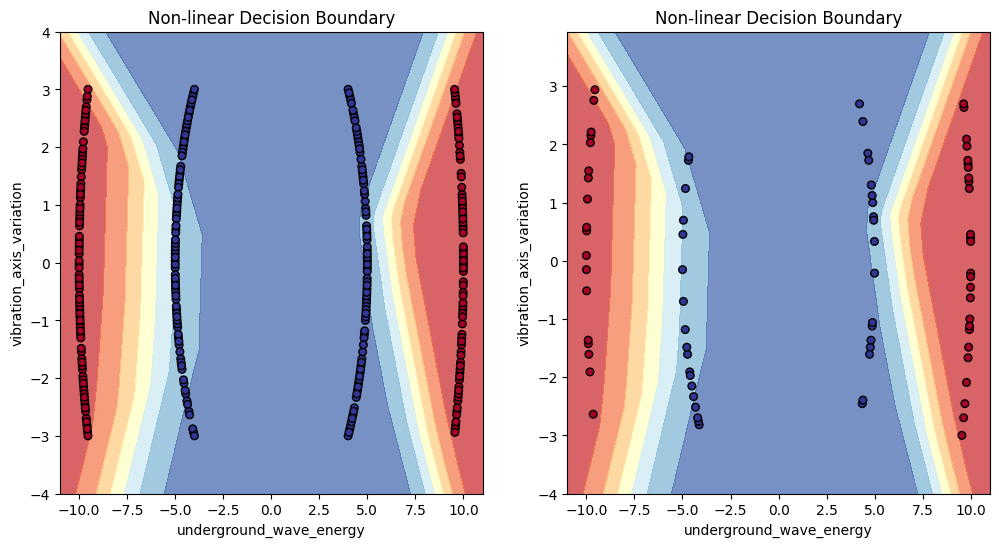

In [14]:
# ── KARAR SINIRI GRAFİĞİ (Decision Boundary) ─────────────────────────────────
# Modelin veriyi nasıl ikiye böldüğünü gösterir.
# Arka plan rengi: mavi → model "0 (olay yok)" diyor, kırmızı → "1 (olay var)" diyor
# Noktalar: gerçek veri. Nokta rengiyle arka plan rengi uyuşuyorsa doğru tahmin.

def plot_nonlinear_decision_boundary(model, X, y):
    # Grafiğin kapsayacağı x ve y aralığını belirle (verinin biraz dışına taş)
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
    
    # Tüm alanı 300x300 noktalık grid'e böl
    # meshgrid: iki diziden koordinat ızgarası oluşturur
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    # Grid noktalarını (300*300=90000 nokta) modele sokabilmek için tensor'a çevir
    # np.c_: iki diziyi sütun olarak yan yana birleştirir → (90000, 2)
    grid_points = torch.tensor(
        np.c_[xx.ravel(), yy.ravel()],
        dtype=torch.float32
    )

    # Her grid noktası için tahmin al (gradyan hesabı gerekmez)
    model.eval()
    with torch.inference_mode():
        logits = model(grid_points)
        preds = torch.sigmoid(logits).numpy().reshape(xx.shape)  # (300,300) olasılık haritası

    # contourf: arka planı olasılığa göre renklendir → karar sınırını görselleştirir
    plt.contourf(xx, yy, preds, cmap=plt.cm.RdYlBu, alpha=0.7)
    
    # Gerçek veri noktalarını üstüne çiz
    plt.scatter(X[:,0], X[:,1], c=y.squeeze(), cmap=plt.cm.RdYlBu, s=30, edgecolor="k")
    plt.xlabel("underground_wave_energy")
    plt.ylabel("vibration_axis_variation")
    plt.title("Non-linear Decision Boundary")

plt.figure(figsize=(12, 6))

# Sol grafik: eğitim verisi üzerindeki karar sınırı
plt.subplot(1, 2, 1)
plt.title("Train")
plot_nonlinear_decision_boundary(model, X_train, y_train)

# Sağ grafik: test verisi üzerindeki karar sınırı (modelin hiç görmediği veri)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_nonlinear_decision_boundary(model, X_test, y_test)

plt.show()